In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

print("YOLO libraries loaded successfully")

YOLO libraries loaded successfully


In [2]:
model_yolo = YOLO("yolov8n.pt")

print("YOLOv8 model loaded successfully")

YOLOv8 model loaded successfully


In [5]:
results = model_yolo("trafficima.jpg")

print("Detection completed")


image 1/1 C:\Users\DELL\OneDrive\Desktop\Final\trafficima.jpg: 544x640 5 persons, 16 cars, 4 motorcycles, 1 bus, 2 trucks, 128.4ms
Speed: 5.8ms preprocess, 128.4ms inference, 1.9ms postprocess per image at shape (1, 3, 544, 640)
Detection completed


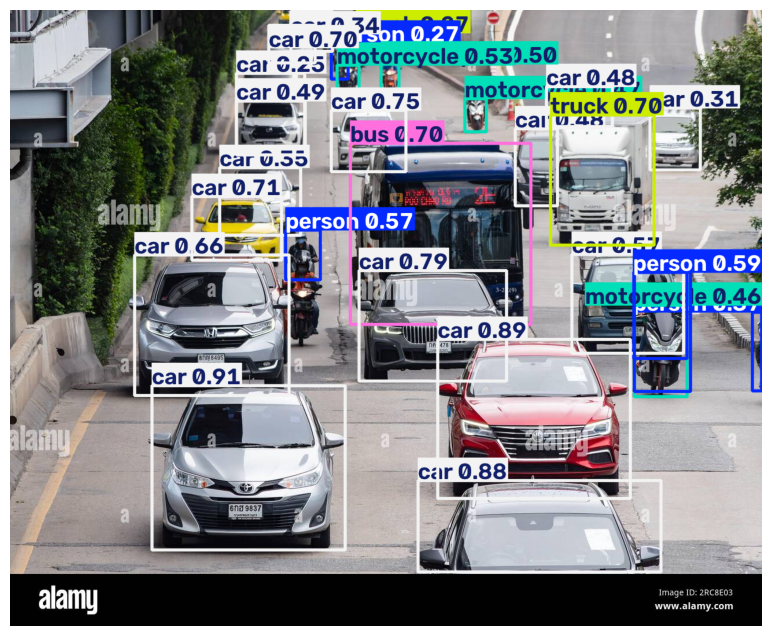

In [6]:
annotated_image = results[0].plot()

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [7]:
vehicle_classes = {
    2: "car",
    3: "motorcycle",
    5: "bus",
    7: "truck"
}

vehicle_counts = {
    "car": 0,
    "motorcycle": 0,
    "bus": 0,
    "truck": 0
}

for box in results[0].boxes:

    class_id = int(box.cls[0])

    if class_id in vehicle_classes:

        vehicle_name = vehicle_classes[class_id]

        vehicle_counts[vehicle_name] += 1


total_vehicles = sum(vehicle_counts.values())

print("Vehicle Counts")
print("----------------------")

for vehicle, count in vehicle_counts.items():
    print(f"{vehicle}: {count}")

print("----------------------")
print("Total Vehicles:", total_vehicles)

Vehicle Counts
----------------------
car: 16
motorcycle: 4
bus: 1
truck: 2
----------------------
Total Vehicles: 23


In [8]:
for box in results[0].boxes:

    class_id = int(box.cls[0])
    confidence = float(box.conf[0])

    if class_id in vehicle_classes:

        print(
            f"{vehicle_classes[class_id]} "
            f"- Confidence: {confidence:.2f}"
        )

car - Confidence: 0.91
car - Confidence: 0.89
car - Confidence: 0.88
car - Confidence: 0.79
car - Confidence: 0.75
car - Confidence: 0.71
car - Confidence: 0.70
truck - Confidence: 0.70
bus - Confidence: 0.70
car - Confidence: 0.66
car - Confidence: 0.57
motorcycle - Confidence: 0.53
motorcycle - Confidence: 0.50
car - Confidence: 0.49
car - Confidence: 0.48
car - Confidence: 0.48
motorcycle - Confidence: 0.47
motorcycle - Confidence: 0.46
car - Confidence: 0.35
car - Confidence: 0.34
car - Confidence: 0.31
truck - Confidence: 0.27
car - Confidence: 0.25


In [12]:
output_path = "yolo_traffic_detection.jpg"

cv2.imwrite(output_path, annotated_image)

print("Saved:", output_path)

Saved: yolo_traffic_detection.jpg
